# EEG 频域分析 - 线性混合效应模型 (LME)

使用线性混合效应模型分析三个组别（ADHD单纯组、ADHD共患阅读困难组、正常发展组）在五个频段上的差异。

**数据结构:**
- 固定效应：组别 (group: adhd/com/td)
- 随机效应：被试 (subject_id)
- 因变量：五个频段功率 (Delta, Theta, Alpha, Beta, Gamma)
- 每个被试有 20+ 个 trials

**分析方法:** 线性混合效应模型 (Linear Mixed-Effects Model)

**输出目录:** `reports/comparison/lme_frequency/`

## 1. 导入和配置

In [1]:
import sys
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 尝试导入 statsmodels
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    STATSMODELS_AVAILABLE = True
    print("✓ statsmodels 已导入")
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("✗ statsmodels 未安装，请运行: pip install statsmodels")

try:
    import mne
    MNE_AVAILABLE = True
    print(f"✓ MNE 版本: {mne.__version__}")
except ImportError:
    MNE_AVAILABLE = False
    print("✗ MNE 未安装")

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("\n" + "=" * 60)
print("配置完成!")
print("=" * 60)

✓ statsmodels 已导入
✓ MNE 版本: 1.8.0

配置完成!


## 2. 数据路径和被试配置

In [3]:
# =============================================================================
# 数据路径配置
# =============================================================================
DATA_ROOT = Path(r'/Users/gaozhenning/Desktop/CodeData/REST_COM-main')
EPOCH_DATA_PATH = DATA_ROOT / 'preprocessing' / 'data' / '6epoch_clean'

# 输出目录
OUTPUT_PATH = DATA_ROOT / 'reports' / 'comparison' / 'lme_frequency'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH = OUTPUT_PATH / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"数据路径: {EPOCH_DATA_PATH}")
print(f"输出路径: {OUTPUT_PATH}")
print(f"图片路径: {FIGURES_PATH}")

# =============================================================================
# 被试分组配置
# =============================================================================
SUBJECT_GROUPS = {
    'adhd': ['018', '029', '031', '037', '038', '045', '075', '091', '094', '117', '132', '134'],
    'com': ['001', '020', '021', '022', '024', '047', '049', '051', '072', '073', '076', '092', '113', '150'],
    'td': ['006', '068', '079', '093', '108', '109', '127', '133'],
}

GROUP_LABELS = {
    'adhd': 'ADHD单纯组',
    'com': 'ADHD共患阅读困难组',
    'td': '正常发展组',
}

# 频段定义
BANDS = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

print("\n被试分组:")
for group, subjects in SUBJECT_GROUPS.items():
    print(f"  {GROUP_LABELS[group]}: {len(subjects)} 被试")
print(f"\n总计: {sum(len(v) for v in SUBJECT_GROUPS.values())} 被试")

数据路径: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/preprocessing/data/6epoch_clean
输出路径: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency
图片路径: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/figures

被试分组:
  ADHD单纯组: 12 被试
  ADHD共患阅读困难组: 14 被试
  正常发展组: 8 被试

总计: 34 被试


## 3. 数据加载 - 批量处理所有被试

In [4]:
def get_group_from_id(sub_id: str) -> str:
    """从被试ID查找所属组别"""
    for group, ids in SUBJECT_GROUPS.items():
        if sub_id in ids:
            return group
    return 'unknown'


def compute_band_powers_from_epochs(epochs, bands):
    """
    计算每个 epoch 的频段功率
    
    Returns:
        Dict[band_name, np.ndarray]: 每个频段的功率，shape = (n_epochs,)
    """
    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        # 使用 MNE 的 compute_psd 然后在指定频率范围内平均
        spectrum = epochs.compute_psd(fmin=fmin, fmax=fmax, n_jobs=1)
        psd = spectrum.get_data()  # 获取功率数据
        # 在频率维度上平均，然后在通道维度上平均
        band_power = psd.mean(axis=1)  # shape: (n_epochs, n_channels)
        # 对所有通道平均，得到每个 epoch 的单一功率值
        band_powers[band_name] = band_power.mean(axis=1)  # shape: (n_epochs,)
    
    return band_powers


print("开始加载所有被试数据...")
print("-" * 60)

all_trials_data = []

for group, subjects in SUBJECT_GROUPS.items():
    print(f"\n处理组别: {GROUP_LABELS[group]}")
    
    group_epoch_path = EPOCH_DATA_PATH / group
    
    for sub_id in subjects:
        epoch_file = group_epoch_path / f'{sub_id}-epo.fif'
        
        if not epoch_file.exists():
            print(f"  ⚠ 被试 {sub_id} 文件不存在")
            continue
        
        try:
            # 加载 epoch 数据
            epochs = mne.read_epochs(epoch_file, preload=True, verbose=False)
            n_epochs = len(epochs)
            
            # 计算每个 trial 的频段功率
            band_powers = compute_band_powers_from_epochs(epochs, BANDS)
            
            # 转换为长格式 DataFrame
            for trial_idx in range(n_epochs):
                for band_name, power in band_powers.items():
                    all_trials_data.append({
                        'subject_id': sub_id,
                        'group': group,
                        'trial': trial_idx,
                        'band': band_name,
                        'power': power[trial_idx],
                    })
            
            print(f"  ✓ {sub_id}: {n_epochs} trials")
            
        except Exception as e:
            print(f"  ✗ {sub_id}: 加载失败 - {str(e)[:50]}")

print("\n" + "-" * 60)
print(f"数据加载完成! 共 {len(all_trials_data)} 条记录")

开始加载所有被试数据...
------------------------------------------------------------

处理组别: ADHD单纯组
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
  ✓ 018: 19 trials
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
  ✓ 029: 22 trials
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitap

## 4. 构建长格式数据框

In [5]:
# 转换为 DataFrame
df = pd.DataFrame(all_trials_data)

print("数据概览:")
print(f"  总记录数: {len(df)}")
print(f"  被试数: {df['subject_id'].nunique()}")
print(f"  组别数: {df['group'].nunique()}")
print(f"  频段数: {df['band'].nunique()}")
print(f"  每组被试数:")
for group in df['group'].unique():
    n_subj = df[df['group'] == group]['subject_id'].nunique()
    n_trials = len(df[df['group'] == group]) / n_subj
    print(f"    {GROUP_LABELS[group]}: {n_subj} 被试, 平均 {n_trials:.1f} trials/人")

print("\n数据前10行:")
print(df.head(10))

print("\n各频段功率统计:")
print(df.groupby('band')['power'].describe())

数据概览:
  总记录数: 3855
  被试数: 34
  组别数: 3
  频段数: 5
  每组被试数:
    ADHD单纯组: 12 被试, 平均 115.4 trials/人
    ADHD共患阅读困难组: 14 被试, 平均 111.1 trials/人
    正常发展组: 8 被试, 平均 114.4 trials/人

数据前10行:
  subject_id group  trial   band         power
0        018  adhd      0  Delta  6.429749e-09
1        018  adhd      0  Theta  9.364332e-10
2        018  adhd      0  Alpha  2.109318e-09
3        018  adhd      0   Beta  1.224328e-10
4        018  adhd      0  Gamma  2.781028e-11
5        018  adhd      1  Delta  6.443744e-09
6        018  adhd      1  Theta  1.003556e-09
7        018  adhd      1  Alpha  1.612945e-09
8        018  adhd      1   Beta  1.182009e-10
9        018  adhd      1  Gamma  2.840758e-11

各频段功率统计:
       count          mean           std           min           25%  \
band                                                                   
Alpha  771.0  1.355423e-09  1.245932e-09  1.628987e-10  5.596015e-10   
Beta   771.0  2.166277e-10  1.415253e-10  5.987862e-11  1.232384e-10   
Delta

## 5. 线性混合效应模型分析

In [6]:
if not STATSMODELS_AVAILABLE:
    raise ImportError("statsmodels 未安装，无法进行线性混合效应模型分析")

print("=" * 60)
print("线性混合效应模型分析")
print("=" * 60)

# 存储结果
lme_results = []

# 对每个频段分别拟合模型
for band_name in BANDS.keys():
    print(f"\n{'=' * 50}")
    print(f"频段: {band_name}")
    print(f"{'=' * 50}")
    
    # 筛选该频段的数据
    band_df = df[df['band'] == band_name].copy()
    
    # 对数变换 (功率值通常呈偏态分布)
    band_df['log_power'] = np.log10(band_df['power'] + 1e-20)
    
    # 线性混合效应模型
    # 公式: log_power ~ group (固定效应) + (1|subject_id) (随机效应)
    model = smf.mixedlm(
        "log_power ~ C(group, Treatment('td'))",  # td 作为参考组
        data=band_df,
        groups=band_df["subject_id"],  # 随机效应: 被试
        re_formula="~1"  # 随机截距
    )
    
    # 拟合模型
    result = model.fit(method='lbfgs')
    
    print("\n模型摘要:")
    print(result.summary())
    
    # 提取固定效应
    fe = result.fe_params
    se = result.bse[:len(fe)]
    pvalues = result.pvalues
    
    # 计算置信区间
    conf_int = result.conf_int()
    
    print("\n固定效应:")
    print(f"  截距 (td组): {fe['Intercept']:.4f} ± {se['Intercept']:.4f}")
    
    for group in ['adhd', 'com']:
        term = f"C(group, Treatment('td'))[T.{group}]"
        if term in fe.index:
            print(f"  {GROUP_LABELS[group]} vs td: β={fe[term]:.4f}, SE={se[term]:.4f}, p={pvalues[term]:.4f}")
    
    # 保存结果
    lme_results.append({
        'band': band_name,
        'model': result,
        'fe_params': fe,
        'pvalues': pvalues,
        'conf_int': conf_int,
    })

print("\n" + "=" * 60)
print("所有频段分析完成!")
print("=" * 60)

线性混合效应模型分析

频段: Delta

模型摘要:
                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        log_power
No. Observations:          771            Method:                    REML     
No. Groups:                34             Scale:                     0.0203   
Min. group size:           15             Log-Likelihood:            335.7859 
Max. group size:           30             Converged:                 Yes      
Mean group size:           22.7                                               
------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                         -8.309    0.081 -102.794 0.000 -8.468 -8.151
C(group, Treatment('td'))[T.adhd]  0.105    0.104    1.004 0.315 -0.100  0.309
C(group, Treatment('td'))[T.com]   0.047    

## 6. 汇总固定效应结果

In [14]:
# 汇总所有频段的固定效应结果
summary_rows = []

for res in lme_results:
    band = res['band']
    fe = res['fe_params']
    pvalues = res['pvalues']
    conf_int = res['conf_int']
    bse = res['model'].bse[:len(fe)]
    
    # 截距 (td组)
    summary_rows.append({
        'band': band,
        'effect': 'Intercept (td)',
        'beta': fe['Intercept'],
        'se': bse[fe.index.get_loc('Intercept')],
        'p_value': pvalues['Intercept'],
        'ci_lower': conf_int.loc['Intercept', 0],
        'ci_upper': conf_int.loc['Intercept', 1],
    })
    
    # 组别效应
    for group in ['adhd', 'com']:
        term = f"C(group, Treatment('td'))[T.{group}]"
        if term in fe.index:
            summary_rows.append({
                'band': band,
                'effect': f'{group} vs td',
                'beta': fe[term],
                'se': bse[fe.index.get_loc(term)],
                'p_value': pvalues[term],
                'ci_lower': conf_int.loc[term, 0],
                'ci_upper': conf_int.loc[term, 1],
            })

summary_df = pd.DataFrame(summary_rows)

print("固定效应汇总表:")
print("-" * 80)
print(summary_df.to_string(index=False))

# 添加显著性标记
def add_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

summary_df['significance'] = summary_df['p_value'].apply(add_significance)

print("\n带显著性标记的汇总表:")
print("-" * 80)
for band in BANDS.keys():
    band_data = summary_df[summary_df['band'] == band]
    print(f"\n{band}:")
    for _, row in band_data.iterrows():
        print(f"  {row['effect']:20s}: β = {row['beta']:+.4f}, p = {row['p_value']:.4f} {row['significance']}")

固定效应汇总表:
--------------------------------------------------------------------------------
 band         effect       beta       se  p_value   ci_lower   ci_upper
Delta Intercept (td)  -8.309356 0.080835 0.000000  -8.467790  -8.150922
Delta     adhd vs td   0.104777 0.104359 0.315376  -0.099763   0.309318
Delta      com vs td   0.046834 0.101346 0.643995  -0.151800   0.245468
Theta Intercept (td)  -8.914896 0.081609 0.000000  -9.074846  -8.754945
Theta     adhd vs td   0.098495 0.105358 0.349861  -0.108003   0.304992
Theta      com vs td   0.042856 0.102310 0.675297  -0.157667   0.243380
Alpha Intercept (td)  -9.036711 0.108929 0.000000  -9.250209  -8.823213
Alpha     adhd vs td   0.008878 0.140629 0.949664  -0.266750   0.284505
Alpha      com vs td  -0.003508 0.136562 0.979508  -0.271165   0.264149
 Beta Intercept (td)  -9.774667 0.077949 0.000000  -9.927445  -9.621889
 Beta     adhd vs td   0.057142 0.100633 0.570155  -0.140095   0.254378
 Beta      com vs td   0.032562 0.097720 0.738

## 7. 事后比较 (Pairwise Comparisons)

In [15]:
print("=" * 60)
print("事后两两比较 (Tukey HSD)")
print("=" * 60)

posthoc_results = []

for band_name in BANDS.keys():
    print(f"\n{band_name}:")
    
    # 筛选该频段的数据
    band_df = df[df['band'] == band_name].copy()
    band_df['log_power'] = np.log10(band_df['power'] + 1e-20)
    
    # Tukey HSD 检验
    tukey = pairwise_tukeyhsd(
        endog=band_df['log_power'],
        groups=band_df['group'],
        alpha=0.05
    )
    
    print(tukey)
    
    # 提取结果
    for i in range(len(tukey.groupsunique)):
        for j in range(i + 1, len(tukey.groupsunique)):
            idx = i * (len(tukey.groupsunique) - 1) + j - 1
            if idx < len(tukey.reject):
                posthoc_results.append({
                    'band': band_name,
                    'group1': tukey.groupsunique[i],
                    'group2': tukey.groupsunique[j],
                    'meandiff': tukey.meandiffs[idx],
                    'p_adj': tukey.pvalues[idx],
                    'reject': tukey.reject[idx],
                })

posthoc_df = pd.DataFrame(posthoc_results)
print("\n" + "=" * 60)
print("事后比较汇总:")
print("=" * 60)
print(posthoc_df.to_string(index=False))

事后两两比较 (Tukey HSD)

Delta:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  adhd    com  -0.0317 0.2903 -0.0813  0.0179  False
  adhd     td  -0.0737 0.0072 -0.1309 -0.0165   True
   com     td   -0.042 0.1833 -0.0979   0.014  False
----------------------------------------------------

Theta:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  adhd    com  -0.0416 0.1024 -0.0893  0.0062  False
  adhd     td  -0.0891 0.0005 -0.1442 -0.0341   True
   com     td  -0.0476 0.0958 -0.1014  0.0063  False
----------------------------------------------------

Alpha:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  adhd    com  -0.0116 0.9109 -0.0775 0.0544  False
  adhd 

## 8. 可视化

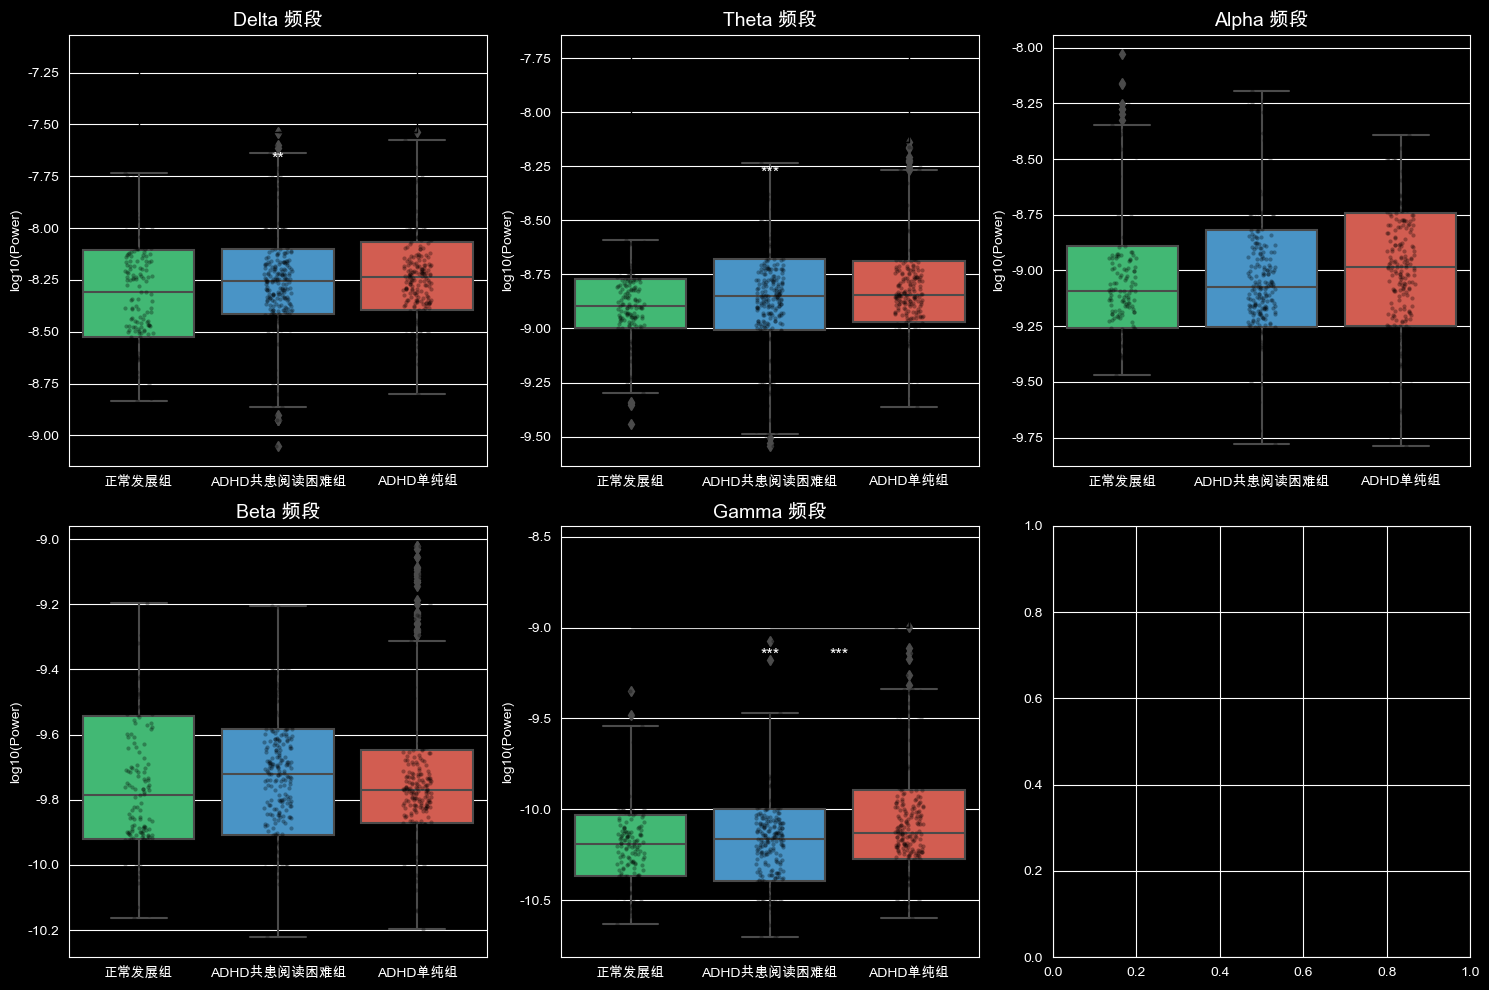


✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/figures/lme_band_powers_boxplot.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, band_name in enumerate(BANDS.keys()):
    ax = axes[idx]
    
    # 筛选该频段的数据
    band_df = df[df['band'] == band_name].copy()
    band_df['log_power'] = np.log10(band_df['power'] + 1e-20)
    
    # 箱线图
    order = ['td', 'com', 'adhd']
    palette = {'td': '#2ecc71', 'com': '#3498db', 'adhd': '#e74c3c'}
    
    sns.boxplot(data=band_df, x='group', y='log_power', order=order, palette=palette, ax=ax)
    
    # 添加散点
    sns.stripplot(data=band_df, x='group', y='log_power', order=order, 
                  color='black', alpha=0.3, size=3, ax=ax)
    
    ax.set_title(f'{band_name} 频段', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('log10(Power)')
    
    # 修改 x 轴标签
    ax.set_xticklabels([GROUP_LABELS[g] for g in order])
    
    # 标注显著性
    band_posthoc = posthoc_df[posthoc_df['band'] == band_name]
    if not band_posthoc.empty:
        y_max = band_df['log_power'].max()
        for _, row in band_posthoc.iterrows():
            if row['reject']:  # 显著
                g1_idx = order.index(row['group1'])
                g2_idx = order.index(row['group2'])
                x = (g1_idx + g2_idx) / 2
                ax.plot([g1_idx, g1_idx, g2_idx, g2_idx], 
                        [y_max * 0.95, y_max, y_max, y_max * 0.95], 
                        'k-', lw=1)
                sig = '***' if row['p_adj'] < 0.001 else '**' if row['p_adj'] < 0.01 else '*'
                ax.text(x, y_max * 1.02, sig, ha='center', fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'lme_band_powers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 已保存: {FIGURES_PATH / 'lme_band_powers_boxplot.png'}")

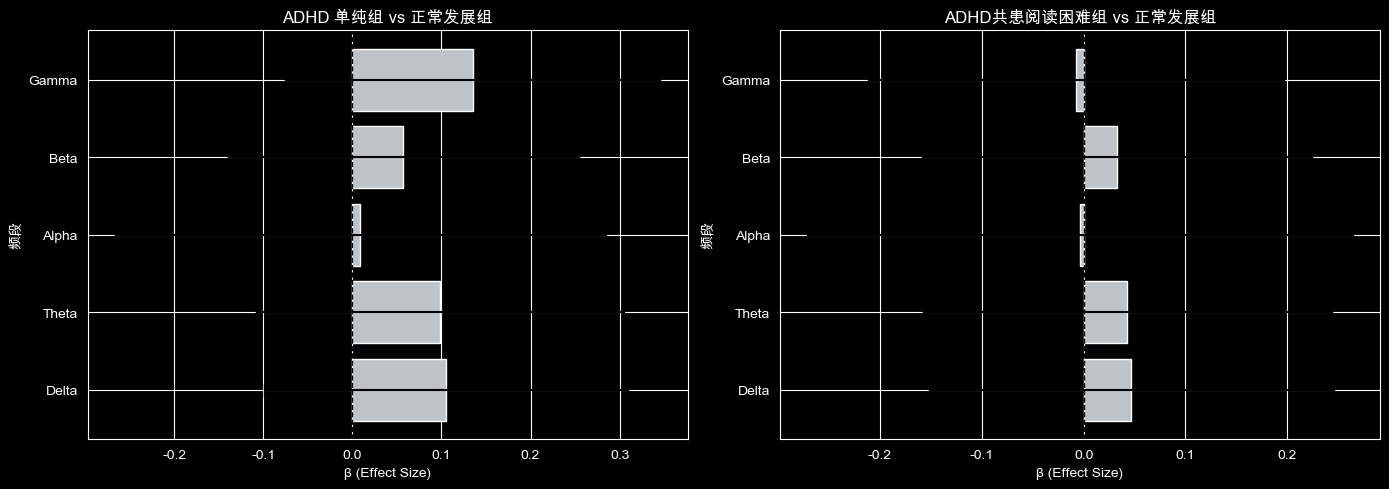


✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/figures/lme_effect_sizes.png


In [17]:
# 可视化: 效应量图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADHD vs TD
ax1 = axes[0]
adhd_vs_td = summary_df[summary_df['effect'] == 'adhd vs td'].copy()
ax1.barh(adhd_vs_td['band'], adhd_vs_td['beta'], 
         xerr=adhd_vs_td['se'] * 1.96,  # 95% CI
         color=['#e74c3c' if p < 0.05 else '#bdc3c7' for p in adhd_vs_td['p_value']],
         capsize=5)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('β (Effect Size)')
ax1.set_ylabel('频段')
ax1.set_title('ADHD 单纯组 vs 正常发展组', fontsize=12, fontweight='bold')

# COM vs TD
ax2 = axes[1]
com_vs_td = summary_df[summary_df['effect'] == 'com vs td'].copy()
ax2.barh(com_vs_td['band'], com_vs_td['beta'],
         xerr=com_vs_td['se'] * 1.96,
         color=['#3498db' if p < 0.05 else '#bdc3c7' for p in com_vs_td['p_value']],
         capsize=5)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('β (Effect Size)')
ax2.set_ylabel('频段')
ax2.set_title('ADHD共患阅读困难组 vs 正常发展组', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'lme_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 已保存: {FIGURES_PATH / 'lme_effect_sizes.png'}")

## 9. 保存结果

In [18]:
# 保存长格式数据
df.to_csv(OUTPUT_PATH / 'trial_level_data.csv', index=False, encoding='utf-8-sig')
print(f"✓ 已保存: {OUTPUT_PATH / 'trial_level_data.csv'}")

# 保存固定效应汇总
summary_df.to_csv(OUTPUT_PATH / 'lme_fixed_effects.csv', index=False, encoding='utf-8-sig')
print(f"✓ 已保存: {OUTPUT_PATH / 'lme_fixed_effects.csv'}")

# 保存事后比较结果
posthoc_df.to_csv(OUTPUT_PATH / 'lme_posthoc.csv', index=False, encoding='utf-8-sig')
print(f"✓ 已保存: {OUTPUT_PATH / 'lme_posthoc.csv'}")

# 保存被试级别汇总 (每个被试的平均功率)
subject_summary = df.groupby(['subject_id', 'group', 'band'])['power'].mean().reset_index()
subject_summary.to_csv(OUTPUT_PATH / 'subject_band_summary.csv', index=False, encoding='utf-8-sig')
print(f"✓ 已保存: {OUTPUT_PATH / 'subject_band_summary.csv'}")

print("\n" + "=" * 60)
print("所有结果已保存!")
print("=" * 60)

✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/trial_level_data.csv
✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/lme_fixed_effects.csv
✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/lme_posthoc.csv
✓ 已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/lme_frequency/subject_band_summary.csv

所有结果已保存!


## 10. 结果报告

In [19]:
print("=" * 70)
print("线性混合效应模型分析结果报告")
print("=" * 70)

print("\n### 分析设计")
print("-" * 70)
print(f"- 因变量: 频段功率 (log10 变换)")
print(f"- 固定效应: 组别 (adhd, com, td)")
print(f"- 随机效应: 被试 (subject_id)")
print(f"- 参考组: td (正常发展组)")
print(f"- 总 trials 数: {len(df)}")
print(f"- 被试数: {df['subject_id'].nunique()} (adhd={len(SUBJECT_GROUPS['adhd'])}, com={len(SUBJECT_GROUPS['com'])}, td={len(SUBJECT_GROUPS['td'])})")

print("\n### 固定效应结果")
print("-" * 70)

for band in BANDS.keys():
    print(f"\n#### {band} 频段")
    band_data = summary_df[summary_df['band'] == band]
    
    for _, row in band_data.iterrows():
        sig = "✓" if row['p_value'] < 0.05 else "✗"
        print(f"  {row['effect']:20s}: β = {row['beta']:+.4f}, "
              f"95% CI [{row['ci_lower']:.4f}, {row['ci_upper']:.4f}], "
              f"p = {row['p_value']:.4f} {sig}")

print("\n### 事后两两比较 (Tukey HSD)")
print("-" * 70)

for band in BANDS.keys():
    print(f"\n#### {band} 频段")
    band_posthoc = posthoc_df[posthoc_df['band'] == band]
    for _, row in band_posthoc.iterrows():
        sig = "✓" if row['reject'] else "✗"
        g1 = GROUP_LABELS.get(row['group1'], row['group1'])
        g2 = GROUP_LABELS.get(row['group2'], row['group2'])
        print(f"  {g1} vs {g2}: "
              f"差异 = {row['meandiff']:+.4f}, p_adj = {row['p_adj']:.4f} {sig}")

print("\n" + "=" * 70)
print("分析完成!")
print("=" * 70)

线性混合效应模型分析结果报告

### 分析设计
----------------------------------------------------------------------
- 因变量: 频段功率 (log10 变换)
- 固定效应: 组别 (adhd, com, td)
- 随机效应: 被试 (subject_id)
- 参考组: td (正常发展组)
- 总 trials 数: 3855
- 被试数: 34 (adhd=12, com=14, td=8)

### 固定效应结果
----------------------------------------------------------------------

#### Delta 频段
  Intercept (td)      : β = -8.3094, 95% CI [-8.4678, -8.1509], p = 0.0000 ✓
  adhd vs td          : β = +0.1048, 95% CI [-0.0998, 0.3093], p = 0.3154 ✗
  com vs td           : β = +0.0468, 95% CI [-0.1518, 0.2455], p = 0.6440 ✗

#### Theta 频段
  Intercept (td)      : β = -8.9149, 95% CI [-9.0748, -8.7549], p = 0.0000 ✓
  adhd vs td          : β = +0.0985, 95% CI [-0.1080, 0.3050], p = 0.3499 ✗
  com vs td           : β = +0.0429, 95% CI [-0.1577, 0.2434], p = 0.6753 ✗

#### Alpha 频段
  Intercept (td)      : β = -9.0367, 95% CI [-9.2502, -8.8232], p = 0.0000 ✓
  adhd vs td          : β = +0.0089, 95% CI [-0.2667, 0.2845], p = 0.9497 ✗
  com vs td         